# U-Phase: Understanding the `ml-25m` Data for the Movie Recommendation App

This notebook is the **U (Understand Data) phase** of the QUAAACK workflow for the Streamlit Movie Recommendation App. In the Q-Phase, the project defined the recommendation problem, the stakeholder needs, the success metrics, and the v1 scope. In this phase, the focus shifts from *what* the system should do to *whether the data can support it reliably*.

For a recommender system, data understanding is not just a cleaning step. It directly shapes what models are realistic, which recommendations can be explained, how severe the cold-start problem will be, and how trustworthy offline evaluation results will be. A model can only be as useful as the interaction and metadata signals it learns from.

This notebook therefore examines the `ml-25m` dataset structure, quality, sparsity, and feature availability with an explicit recommender-systems lens. The goal is to produce a clear and evidence-based foundation for the next phase (`AAA`), where baseline and candidate recommenders will be built and evaluated.


## How to Read This Notebook (and Why It Is Written This Way)

This notebook is written for a mixed audience. Technical readers should be able to inspect the code, data checks, and EDA outputs. Non-technical readers should be able to follow the interpretation in plain language and understand why each result matters for the recommendation app.

To match the project writing rules, the notebook uses **prose-first explanations** rather than long bullet lists. Short lists appear only where the task explicitly requires itemized information (for example, the dataset file inventory and the named evaluation constraints). Each chart, table, or diagram is followed by a short explanation that states what it shows and why it matters for recommendation quality or app behavior.

The code is intentionally memory-aware where practical, especially when discussing `ratings.csv` and `genome-scores.csv`. However, this is still a real EDA notebook, so some steps may take time when run on the full dataset.


In [1]:
from __future__ import annotations

from pathlib import Path
import random
import textwrap
import warnings

try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "This notebook requires numpy, pandas, and matplotlib. "
        "Install them in the notebook environment before running U-Phase."
    ) from exc

try:
    import seaborn as sns
    _HAS_SEABORN = True
except ModuleNotFoundError:
    sns = None
    _HAS_SEABORN = False

from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = Path("ml-25m")
ARTIFACT_DIR = Path("artifacts")

if _HAS_SEABORN:
    sns.set_theme(style="whitegrid", context="notebook")
else:
    plt.style.use("ggplot")

RECOMMENDED_K = 10  # referenced later for ranking-oriented interpretations

print(f"Data directory: {DATA_DIR.resolve()}")
print(f"Random seed fixed at: {SEED}")
print(f"Seaborn available: {_HAS_SEABORN}")


Data directory: /workspace/ml-25m
Random seed fixed at: 42
Seaborn available: False


The setup cell imports the libraries used for profiling and visualization and fixes a random seed for reproducibility. The seed is not a major factor in this U-Phase because most analyses are deterministic, but it keeps sampling behavior stable if you choose to use optional samples for faster local iteration.

The import error message is intentional. This shell environment does not currently include the data-science libraries, so the notebook is delivered as runnable code but is not executed in this turn. In a notebook environment with `pandas` and `matplotlib`, the cells below should run as designed.


## 1. Dataset Inventory (`ml-25m`) and High-Level Documentation Summary

The `ml-25m` folder is the source-of-truth dataset directory for this project (`DATA.md`). Before we analyze distributions or data quality, it is important to document what files exist, what role they play in the recommender, and which ones are core versus optional for v1. This prevents the modeling phase from quietly depending on a file that was never evaluated for runtime cost or quality.

The code below builds a file inventory table using the local `ml-25m` directory, including file size and exact row counts for CSV files (counted by line scan, which may take a little time for larger files). It also extracts the first summary paragraph from `ml-25m/README.txt` so the notebook stays anchored to the dataset documentation.


In [2]:
FILE_ROLE_MAP = {
    "ratings.csv": {
        "v1_priority": "Required (v1 core)",
        "role": "User-item explicit interactions (ratings) for collaborative signals and evaluation.",
    },
    "movies.csv": {
        "v1_priority": "Required (v1 core)",
        "role": "Movie metadata (title, genres) for display, filtering, and simple content features.",
    },
    "tags.csv": {
        "v1_priority": "Optional (v1 enrichment)",
        "role": "User-provided tags for content enrichment and explainability experiments.",
    },
    "links.csv": {
        "v1_priority": "Optional (v1/v1.1 utility)",
        "role": "External IDs (IMDb/TMDb) for poster lookups and metadata extensions.",
    },
    "genome-scores.csv": {
        "v1_priority": "Optional advanced (large)",
        "role": "Dense tag relevance scores for richer content/hybrid models; expensive to process.",
    },
    "genome-tags.csv": {
        "v1_priority": "Optional advanced support",
        "role": "Dictionary of tag IDs used by the genome scores file.",
    },
    "README.txt": {
        "v1_priority": "Documentation",
        "role": "Official dataset description, limits, file formats, and usage notes.",
    },
}


def file_size_mb(path: Path) -> float:
    return path.stat().st_size / (1024 * 1024)


def count_csv_rows(path: Path) -> int:
    # Exact row count by line scan (header excluded). Slowest for large files, but reproducible.
    with path.open("r", encoding="utf-8", errors="replace", newline="") as f:
        return max(sum(1 for _ in f) - 1, 0)


def extract_readme_summary(readme_path: Path) -> str:
    text = readme_path.read_text(encoding="utf-8", errors="replace")
    lines = text.splitlines()
    in_summary = False
    summary_lines = []
    for line in lines:
        stripped = line.strip()
        if not in_summary:
            if stripped.lower() == "summary":
                in_summary = True
            continue
        if stripped.lower() == "usage license":
            break
        if not stripped or set(stripped) == {"="}:
            if summary_lines:
                break
            continue
        summary_lines.append(stripped)
    return " ".join(summary_lines)

records = []
for name, meta in FILE_ROLE_MAP.items():
    path = DATA_DIR / name
    exists = path.exists()
    rec = {
        "file": name,
        "exists": exists,
        "size_mb": round(file_size_mb(path), 2) if exists else np.nan,
        "row_count": count_csv_rows(path) if exists and path.suffix == ".csv" else np.nan,
        "v1_priority": meta["v1_priority"],
        "role": meta["role"],
    }
    records.append(rec)

inventory_df = pd.DataFrame(records).sort_values(["exists", "file"], ascending=[False, True])
display(inventory_df)

readme_summary = extract_readme_summary(DATA_DIR / "README.txt") if (DATA_DIR / "README.txt").exists() else "README.txt not found."
print("README summary paragraph:\n")
print(textwrap.fill(readme_summary, width=110))


,file,exists,size_mb,row_count,v1_priority,role
6,README.txt,True,0.01,NaN,Documentation,"Official dataset description, limits, file for..."
4,genome-scores.csv,True,415.00,15584448.0,Optional advanced (large),Dense tag relevance scores for richer content/...
5,genome-tags.csv,True,0.02,1128.0,Optional advanced support,Dictionary of tag IDs used by the genome score...
3,links.csv,True,1.31,62423.0,Optional (v1/v1.1 utility),External IDs (IMDb/TMDb) for poster lookups an...
1,movies.csv,True,2.90,62423.0,Required (v1 core),"Movie metadata (title, genres) for display, fi..."
0,ratings.csv,True,646.84,25000095.0,Required (v1 core),User-item explicit interactions (ratings) for ...
2,tags.csv,True,37.01,1093360.0,Optional (v1 enrichment),User-provided tags for content enrichment and ...


README summary paragraph:

This dataset (ml-25m) describes 5-star rating and free-text tagging activity from
[MovieLens](http://movielens.org), a movie recommendation service. It contains 25000095 ratings and 1093360
tag applications across 62423 movies. These data were created by 162541 users between January 09, 1995 and
November 21, 2019. This dataset was generated on November 21, 2019.


The inventory table documents the `ml-25m` files in terms that are immediately useful for the recommender project rather than only listing filenames. It also makes the v1 priority explicit, which helps separate the core app path (`ratings.csv` and `movies.csv`) from optional enrichment paths. The printed README summary paragraph below the table anchors this inventory to the official dataset documentation rather than assumptions made in the notebook.

What this shows in practice is that the dataset is rich enough to support multiple recommendation strategies, but not every file needs to be part of the first version. That matters for the Streamlit app because loading and processing cost affects responsiveness, and the project explicitly prioritizes a fast, explainable v1 over maximum feature complexity.


## 2. Data Loading and Schema Inspection

This section loads the core data files used for recommender modeling and app display, then inspects columns, dtypes, row counts, and memory usage. It also performs a selective inspection of `genome-scores.csv` because that file is large and may not be necessary for a v1 recommender path.

The guiding principle is simple: load what we need in full for core EDA (`ratings.csv`, `movies.csv`, `tags.csv`, `links.csv`, `genome-tags.csv`), and inspect the largest optional file (`genome-scores.csv`) in a memory-aware way before deciding whether it belongs in the v1 modeling path.


In [3]:
RATINGS_DTYPES = {
    "userId": "int32",
    "movieId": "int32",
    "rating": "float32",
    "timestamp": "int64",
}

MOVIES_DTYPES = {
    "movieId": "int32",
    "title": "string",
    "genres": "string",
}

TAGS_DTYPES = {
    "userId": "int32",
    "movieId": "int32",
    "tag": "string",
    "timestamp": "int64",
}

LINKS_DTYPES = {
    "movieId": "int32",
    "imdbId": "Int64",
    "tmdbId": "Int64",
}

GENOME_SCORES_DTYPES = {
    "movieId": "int32",
    "tagId": "int32",
    "relevance": "float32",
}

GENOME_TAGS_DTYPES = {
    "tagId": "int32",
    "tag": "string",
}


def df_memory_mb(df: pd.DataFrame) -> float:
    return float(df.memory_usage(deep=True).sum()) / (1024 * 1024)


def schema_table(name: str, df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "dataset": name,
            "column": df.columns,
            "dtype": [str(dt) for dt in df.dtypes.values],
        }
    )

print("Loading core files (this may take time for ratings.csv)...")
movies_df = pd.read_csv(DATA_DIR / "movies.csv", dtype=MOVIES_DTYPES)
ratings_df = pd.read_csv(DATA_DIR / "ratings.csv", dtype=RATINGS_DTYPES)
tags_df = pd.read_csv(DATA_DIR / "tags.csv", dtype=TAGS_DTYPES)
links_df = pd.read_csv(DATA_DIR / "links.csv", dtype=LINKS_DTYPES)
genome_tags_df = pd.read_csv(DATA_DIR / "genome-tags.csv", dtype=GENOME_TAGS_DTYPES)

ratings_df["timestamp_dt"] = pd.to_datetime(ratings_df["timestamp"], unit="s", utc=True, errors="coerce")
tags_df["timestamp_dt"] = pd.to_datetime(tags_df["timestamp"], unit="s", utc=True, errors="coerce")

GENOME_SAMPLE_ROWS = 200_000
genome_scores_sample_df = pd.read_csv(
    DATA_DIR / "genome-scores.csv",
    dtype=GENOME_SCORES_DTYPES,
    nrows=GENOME_SAMPLE_ROWS,
)

print("Core data loaded.")
print(f"ratings_df shape: {ratings_df.shape}")
print(f"movies_df shape: {movies_df.shape}")
print(f"tags_df shape: {tags_df.shape}")
print(f"links_df shape: {links_df.shape}")
print(f"genome_tags_df shape: {genome_tags_df.shape}")
print(f"genome_scores_sample_df shape: {genome_scores_sample_df.shape}")


Loading core files (this may take time for ratings.csv)...
Core data loaded.
ratings_df shape: (25000095, 5)
movies_df shape: (62423, 3)
tags_df shape: (1093360, 5)
links_df shape: (62423, 3)
genome_tags_df shape: (1128, 2)
genome_scores_sample_df shape: (200000, 3)


In [4]:
schema_tables = pd.concat(
    [
        schema_table("ratings", ratings_df),
        schema_table("movies", movies_df),
        schema_table("tags", tags_df),
        schema_table("links", links_df),
        schema_table("genome_tags", genome_tags_df),
        schema_table("genome_scores_sample", genome_scores_sample_df),
    ],
    ignore_index=True,
)
display(schema_tables)

row_count_lookup = inventory_df.set_index("file")["row_count"].to_dict() if "inventory_df" in globals() else {}
full_genome_rows = row_count_lookup.get("genome-scores.csv", np.nan)

memory_summary_df = pd.DataFrame(
    [
        {
            "dataset": "ratings (full)",
            "rows_loaded": len(ratings_df),
            "memory_mb": round(df_memory_mb(ratings_df), 2),
            "notes": "Core interaction table; largest in-memory dataframe in this notebook.",
        },
        {
            "dataset": "movies (full)",
            "rows_loaded": len(movies_df),
            "memory_mb": round(df_memory_mb(movies_df), 2),
            "notes": "Small enough for repeated joins and genre analysis.",
        },
        {
            "dataset": "tags (full)",
            "rows_loaded": len(tags_df),
            "memory_mb": round(df_memory_mb(tags_df), 2),
            "notes": "Useful for content enrichment and text quality checks.",
        },
        {
            "dataset": "links (full)",
            "rows_loaded": len(links_df),
            "memory_mb": round(df_memory_mb(links_df), 2),
            "notes": "Small metadata bridge table.",
        },
        {
            "dataset": "genome-tags (full)",
            "rows_loaded": len(genome_tags_df),
            "memory_mb": round(df_memory_mb(genome_tags_df), 2),
            "notes": "Small lookup table for genome tag IDs.",
        },
        {
            "dataset": "genome-scores (sample)",
            "rows_loaded": len(genome_scores_sample_df),
            "memory_mb": round(df_memory_mb(genome_scores_sample_df), 2),
            "notes": f"Sample of {GENOME_SAMPLE_ROWS:,} rows for schema and memory estimation.",
        },
    ]
)

if pd.notna(full_genome_rows) and len(genome_scores_sample_df) > 0:
    sample_mem = df_memory_mb(genome_scores_sample_df)
    est_full_mem = sample_mem * (float(full_genome_rows) / len(genome_scores_sample_df))
    memory_summary_df = pd.concat(
        [
            memory_summary_df,
            pd.DataFrame(
                [
                    {
                        "dataset": "genome-scores (estimated full in-memory)",
                        "rows_loaded": int(full_genome_rows),
                        "memory_mb": round(est_full_mem, 2),
                        "notes": "Estimate from sample dtype footprint; actual usage may vary.",
                    }
                ]
            ),
        ],
        ignore_index=True,
    )

display(memory_summary_df)

preview_tables = {
    "ratings": ratings_df.head(),
    "movies": movies_df.head(),
    "tags": tags_df.head(),
    "links": links_df.head(),
    "genome_tags": genome_tags_df.head(),
    "genome_scores_sample": genome_scores_sample_df.head(),
}

for name, preview in preview_tables.items():
    print(f"\n{name} preview:")
    display(preview)


,dataset,column,dtype
0,ratings,userId,int32
1,ratings,movieId,int32
2,ratings,rating,float32
3,ratings,timestamp,int64
4,ratings,timestamp_dt,"datetime64[s, UTC]"
5,movies,movieId,int32
6,movies,title,string
7,movies,genres,string
8,tags,userId,int32
9,tags,movieId,int32


,dataset,rows_loaded,memory_mb,notes
0,ratings (full),25000095,667.57,Core interaction table; largest in-memory data...
1,movies (full),62423,9.40,Small enough for repeated joins and genre anal...
2,tags (full),1093360,95.64,Useful for content enrichment and text quality...
3,links (full),62423,1.31,Small metadata bridge table.
4,genome-tags (full),1128,0.08,Small lookup table for genome tag IDs.
5,genome-scores (sample),200000,2.29,"Sample of 200,000 rows for schema and memory e..."
6,genome-scores (estimated full in-memory),15584448,178.36,Estimate from sample dtype footprint; actual u...



ratings preview:


,userId,movieId,rating,timestamp,timestamp_dt
0,1,296,5.0,1147880044,2006-05-17 15:34:04+00:00
1,1,306,3.5,1147868817,2006-05-17 12:26:57+00:00
2,1,307,5.0,1147868828,2006-05-17 12:27:08+00:00
3,1,665,5.0,1147878820,2006-05-17 15:13:40+00:00
4,1,899,3.5,1147868510,2006-05-17 12:21:50+00:00



movies preview:


...

,movieId,imdbId,tmdbId
0,1,114709,862
1,2,113497,8844
2,3,113228,15602
3,4,114885,31357
4,5,113041,11862



genome_tags preview:


,tagId,tag
0,1,007
1,2,007 (series)
2,3,18th century
3,4,1920s
4,5,1930s



genome_scores_sample preview:


,movieId,tagId,relevance
0,1,1,0.02875
1,1,2,0.02375
2,1,3,0.06250
3,1,4,0.07575
4,1,5,0.14075


The schema table confirms the columns and dtypes that matter for recommender modeling. In particular, `ratings.csv` provides the explicit feedback signal (`rating`) and time information (`timestamp`), while `movies.csv` provides the metadata needed for display, filtering, and basic content-based features. The tags and genome files expand content options but are not equally cheap to use.

The memory summary table is especially important for later design decisions. It shows why `ratings.csv` and `genome-scores.csv` must be treated carefully in both notebooks and the Streamlit app. The small preview tables printed below it are not just sanity checks; they confirm that the loaded schemas and parsed timestamp columns look consistent before deeper EDA begins.

Even before modeling, this section supports the project decision to keep heavy processing offline and to defer expensive features unless they clearly improve recommendation quality.


## 3. Data Quality Checks (Recommender-Focused)

The goal of data quality checks in a recommender project is not only to find broken rows. It is also to identify issues that can distort ranking evaluation, weaken explainability, or cause silent failures in app filters and joins. For example, malformed genre values can break filtering logic, and timestamp parsing errors can invalidate chronological splits.

The checks below focus on the core modeling and enrichment files used in this project, with a lighter touch on the large genome scores file (sample-based inspection) to keep runtime practical in early EDA.


In [5]:
ALLOWED_RATINGS = set(np.arange(0.5, 5.0 + 0.5, 0.5))
ALLOWED_GENRES = {
    "Action", "Adventure", "Animation", "Children's", "Comedy", "Crime", "Documentary",
    "Drama", "Fantasy", "Film-Noir", "Horror", "Musical", "Mystery", "Romance",
    "Sci-Fi", "Thriller", "War", "Western", "(no genres listed)"
}


def null_summary(df: pd.DataFrame) -> dict:
    return {col: int(val) for col, val in df.isna().sum().items() if int(val) > 0}


def build_quality_record(name: str, df: pd.DataFrame, key_cols: list[str] | None = None) -> dict:
    record = {
        "dataset": name,
        "rows": len(df),
        "duplicate_rows": int(df.duplicated().sum()),
        "total_missing_cells": int(df.isna().sum().sum()),
    }
    if key_cols:
        record["duplicate_key_rows"] = int(df.duplicated(subset=key_cols).sum())
    else:
        record["duplicate_key_rows"] = np.nan
    return record

quality_records = []
quality_records.append(build_quality_record("ratings", ratings_df, ["userId", "movieId", "timestamp"]))
quality_records.append(build_quality_record("movies", movies_df, ["movieId"]))
quality_records.append(build_quality_record("tags", tags_df, ["userId", "movieId", "tag", "timestamp"]))
quality_records.append(build_quality_record("links", links_df, ["movieId"]))
quality_records.append(build_quality_record("genome_tags", genome_tags_df, ["tagId"]))
quality_records.append(build_quality_record("genome_scores_sample", genome_scores_sample_df, ["movieId", "tagId"]))

quality_summary_df = pd.DataFrame(quality_records)
display(quality_summary_df)

invalid_ratings_count = int((~ratings_df["rating"].isin(ALLOWED_RATINGS)).sum())
ratings_timestamp_parse_failures = int(ratings_df["timestamp_dt"].isna().sum())
tags_timestamp_parse_failures = int(tags_df["timestamp_dt"].isna().sum())

movies_genres_series = movies_df["genres"].astype("string")
movies_genres_normalized = movies_genres_series.fillna("").str.strip()
missing_or_empty_genres = int(movies_genres_normalized.eq("").sum())
double_pipe_genres = int(movies_genres_series.fillna("").str.contains(r"\|\|", regex=True).sum())

exploded_genres = (
    movies_df[["movieId", "genres"]]
    .assign(genres=lambda d: d["genres"].fillna(""))
    .assign(genre=lambda d: d["genres"].str.split(r"\|"))
    .explode("genre")
)
exploded_genres["genre"] = exploded_genres["genre"].astype("string").str.strip()
nonempty_genres = exploded_genres.loc[exploded_genres["genre"].notna() & exploded_genres["genre"].ne(""), "genre"]
invalid_genre_labels = sorted(set(nonempty_genres.unique()) - ALLOWED_GENRES)

missing_tag_values = int(tags_df["tag"].isna().sum())
empty_tag_strings = int(tags_df["tag"].astype("string").fillna("").str.strip().eq("").sum())

rating_movie_ids = set(ratings_df["movieId"].unique())
movie_catalog_ids = set(movies_df["movieId"].unique())
ratings_missing_movie_match = int(len(rating_movie_ids - movie_catalog_ids))
movies_without_ratings = int(len(movie_catalog_ids - rating_movie_ids))

quality_detail_df = pd.DataFrame(
    [
        {"check": "Invalid rating values in ratings.csv", "value": invalid_ratings_count},
        {"check": "Timestamp parse failures in ratings.csv", "value": ratings_timestamp_parse_failures},
        {"check": "Timestamp parse failures in tags.csv", "value": tags_timestamp_parse_failures},
        {"check": "Missing/empty genre strings in movies.csv", "value": missing_or_empty_genres},
        {"check": "Genre strings containing double delimiters (||)", "value": double_pipe_genres},
        {"check": "Invalid genre labels outside MovieLens vocabulary", "value": len(invalid_genre_labels)},
        {"check": "Missing tag values (NaN) in tags.csv", "value": missing_tag_values},
        {"check": "Empty/whitespace-only tags in tags.csv", "value": empty_tag_strings},
        {"check": "movieId values in ratings.csv not found in movies.csv", "value": ratings_missing_movie_match},
        {"check": "movieId values in movies.csv with no ratings.csv match", "value": movies_without_ratings},
    ]
)
display(quality_detail_df)

if invalid_genre_labels:
    print("Unexpected genre labels found:", invalid_genre_labels[:20])
else:
    print("No unexpected genre labels found outside the MovieLens vocabulary.")

print("\nColumn-level null summaries (non-zero only):")
for name, df in [
    ("ratings", ratings_df),
    ("movies", movies_df),
    ("tags", tags_df),
    ("links", links_df),
    ("genome_tags", genome_tags_df),
    ("genome_scores_sample", genome_scores_sample_df),
]:
    print(f"- {name}: {null_summary(df)}")


,dataset,rows,duplicate_rows,total_missing_cells,duplicate_key_rows
0,ratings,25000095,0,0,0
1,movies,62423,0,0,0
2,tags,1093360,0,16,0
3,links,62423,0,107,0
4,genome_tags,1128,0,0,0
5,genome_scores_sample,200000,0,0,0


,check,value
0,Invalid rating values in ratings.csv,0
1,Timestamp parse failures in ratings.csv,0
2,Timestamp parse failures in tags.csv,0
3,Missing/empty genre strings in movies.csv,0
4,Genre strings containing double delimiters (||),0
5,Invalid genre labels outside MovieLens vocabulary,2
6,Missing tag values (NaN) in tags.csv,16
7,Empty/whitespace-only tags in tags.csv,25
8,movieId values in ratings.csv not found in mov...,0
9,movieId values in movies.csv with no ratings.c...,3376


Unexpected genre labels found: ['Children', 'IMAX']

Column-level null summaries (non-zero only):
- ratings: {}
- movies: {}
- tags: {'tag': 16}
- links: {'tmdbId': 107}
- genome_tags: {}
- genome_scores_sample: {}


The quality summary table reports the checks that most directly affect recommender behavior: duplicate rows, missing values, timestamp parsing, rating validity, and metadata cleanliness. The second table adds recommender-specific checks such as whether `movieId` values in `ratings.csv` are missing from `movies.csv`, because that mismatch would break joins and lead to missing titles in the app. The printed null-summary lines that follow the tables provide a quick column-level view of where missing values are concentrated.

What this means for the recommendation app is straightforward: if timestamps do not parse correctly, chronological evaluation can become invalid; if genres are malformed, filtering and content features can degrade; and if catalog joins fail, the app may produce recommendations it cannot display properly. Running these checks early reduces debugging effort later in the AAA phase.


## 4. Exploratory Analysis: Core Recommender Insights

This section focuses on the patterns that most strongly influence recommendation quality and model choice. The objective is not generic EDA for its own sake. Instead, each chart is tied to a practical recommender question, such as whether the data are highly skewed, how strong the popularity long tail is, and how severe user/item activity imbalance might be.

To support multiple plots efficiently, the first code cell computes reusable user-level and movie-level aggregates from `ratings.csv`.


In [6]:
# Reusable aggregates for recommender-oriented EDA
user_stats_df = (
    ratings_df.groupby("userId")
    .agg(
        rating_count=("rating", "size"),
        avg_rating=("rating", "mean"),
    )
    .reset_index()
)

movie_stats_df = (
    ratings_df.groupby("movieId")
    .agg(
        rating_count=("rating", "size"),
        avg_rating=("rating", "mean"),
    )
    .reset_index()
)

ratings_df["rating_year"] = ratings_df["timestamp_dt"].dt.year.astype("Int64")
ratings_by_year_df = (
    ratings_df.dropna(subset=["rating_year"])
    .groupby("rating_year")
    .size()
    .rename("rating_count")
    .reset_index()
    .sort_values("rating_year")
)

print(f"Unique users in ratings.csv: {ratings_df['userId'].nunique():,}")
print(f"Unique movies in ratings.csv: {ratings_df['movieId'].nunique():,}")
print(f"Rows in user_stats_df: {len(user_stats_df):,}")
print(f"Rows in movie_stats_df: {len(movie_stats_df):,}")
print(f"Rows in ratings_by_year_df: {len(ratings_by_year_df):,}")


Unique users in ratings.csv: 162,541
Unique movies in ratings.csv: 59,047
Rows in user_stats_df: 162,541
Rows in movie_stats_df: 59,047
Rows in ratings_by_year_df: 25


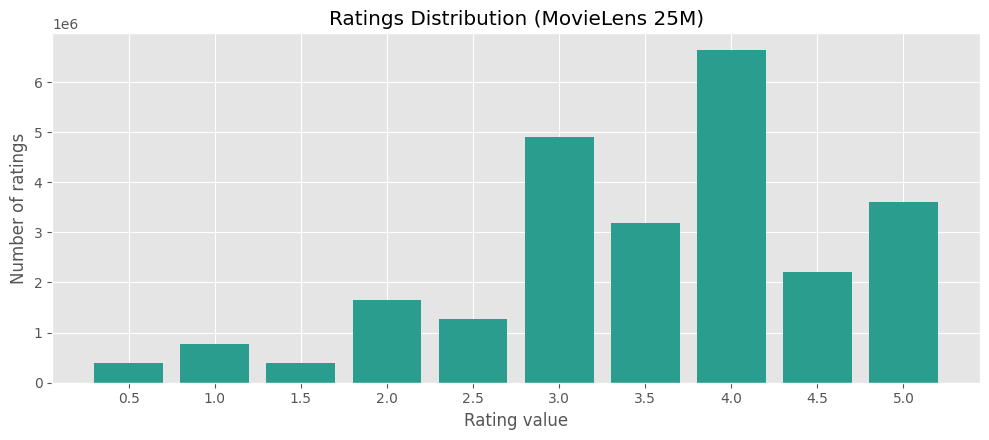

,rating,count
0,0.5,393068
1,1.0,776815
2,1.5,399490
3,2.0,1640868
4,2.5,1262797
5,3.0,4896928
6,3.5,3177318
7,4.0,6639798
8,4.5,2200539
9,5.0,3612474


In [7]:
# Ratings distribution (explicit feedback values)
rating_counts = ratings_df["rating"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(rating_counts.index.astype(str), rating_counts.values, color="#2a9d8f")
ax.set_title("Ratings Distribution (MovieLens 25M)")
ax.set_xlabel("Rating value")
ax.set_ylabel("Number of ratings")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

display(rating_counts.rename_axis("rating").reset_index(name="count"))


This chart and table show how often each rating value appears in `ratings.csv`. Because MovieLens uses half-star increments, the distribution reveals both user rating habits and how concentrated the explicit feedback signal is across the 0.5 to 5.0 scale.

This matters for recommendation modeling because the rating distribution affects relevance thresholds and the conversion from ratings to ranking targets in later evaluation. If ratings cluster heavily at certain values, the project must define the "relevant" cutoff carefully (for example, `rating >= 4.0`) to avoid misleading offline metrics.


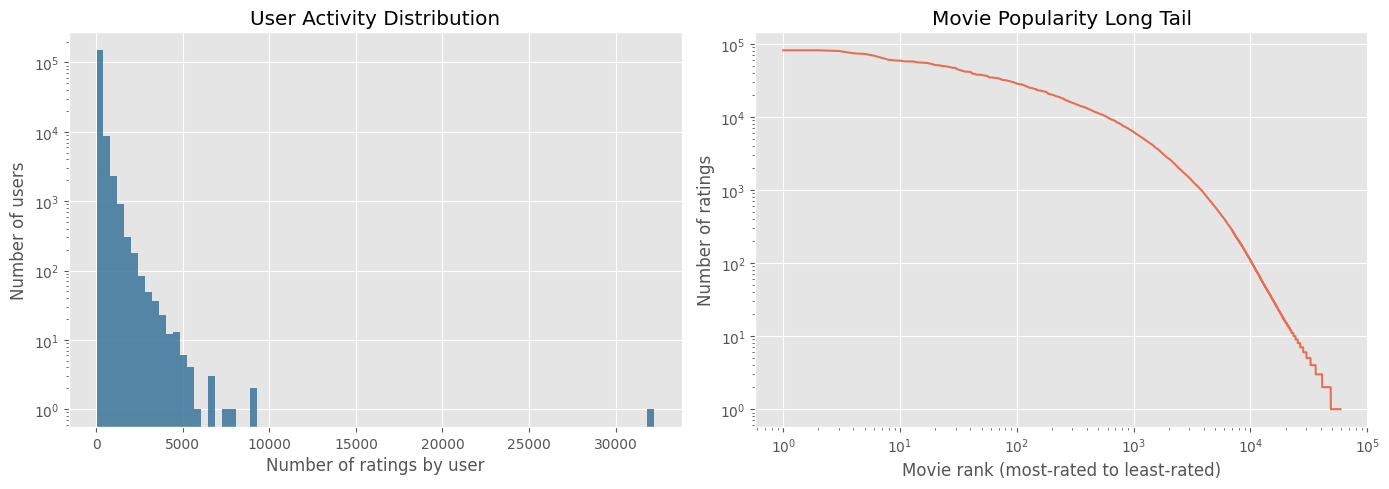

In [8]:
# User activity distribution and movie popularity long-tail
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(user_stats_df["rating_count"], bins=80, color="#457b9d", alpha=0.9)
axes[0].set_title("User Activity Distribution")
axes[0].set_xlabel("Number of ratings by user")
axes[0].set_ylabel("Number of users")
axes[0].set_yscale("log")

sorted_movie_counts = movie_stats_df["rating_count"].sort_values(ascending=False).reset_index(drop=True)
movie_ranks = np.arange(1, len(sorted_movie_counts) + 1)
axes[1].plot(movie_ranks, sorted_movie_counts.values, color="#e76f51")
axes[1].set_title("Movie Popularity Long Tail")
axes[1].set_xlabel("Movie rank (most-rated to least-rated)")
axes[1].set_ylabel("Number of ratings")
axes[1].set_yscale("log")
axes[1].set_xscale("log")

plt.tight_layout()
plt.show()


The left chart shows how uneven user activity is: many users contribute relatively few ratings, while a smaller set of users contribute many more. The right chart shows the long-tail nature of movie popularity, where a small number of titles attract large numbers of ratings and a large number of titles receive much less attention.

This pattern is central to recommender design. It helps explain why cold-start and sparsity are persistent problems even in a large dataset, and it also explains why popularity-based baselines can look strong unless we evaluate carefully by user segment and coverage.


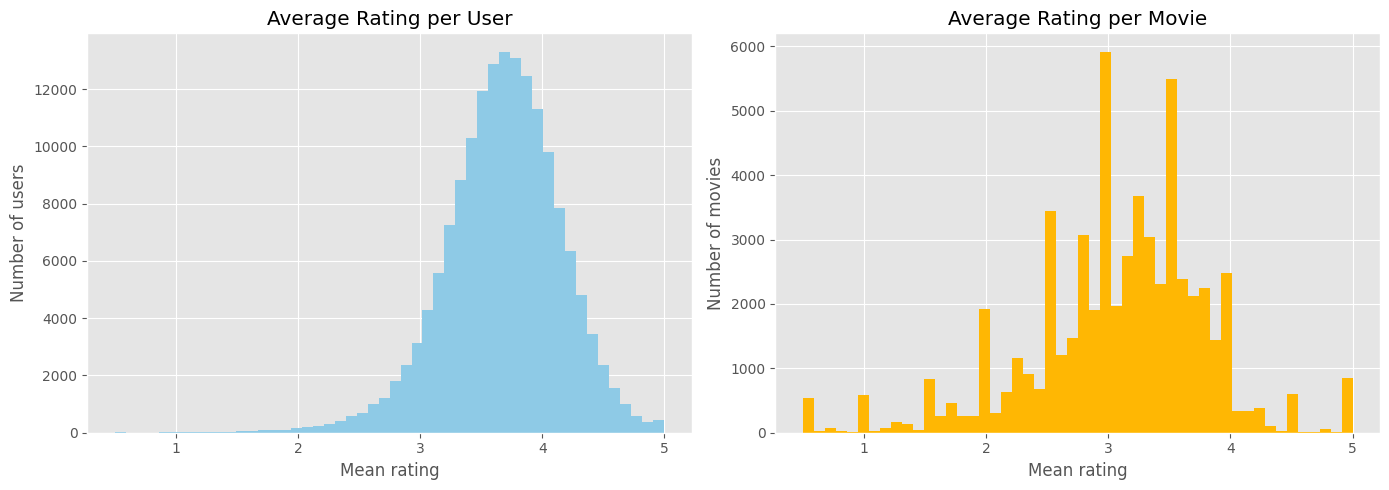

,user_avg_rating,movie_avg_rating
count,162541.000000,59047.000000
mean,3.679205,3.071374
std,0.477368,0.739840
min,0.500000,0.500000
10%,3.096154,2.088235
25%,3.398747,2.687500
50%,3.700000,3.150000
75%,4.000000,3.500000
90%,4.254386,3.866324
max,5.000000,5.000000


In [9]:
# Average rating distributions (user-level and movie-level) + summary statistics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(user_stats_df["avg_rating"], bins=50, color="#8ecae6")
axes[0].set_title("Average Rating per User")
axes[0].set_xlabel("Mean rating")
axes[0].set_ylabel("Number of users")

axes[1].hist(movie_stats_df["avg_rating"], bins=50, color="#ffb703")
axes[1].set_title("Average Rating per Movie")
axes[1].set_xlabel("Mean rating")
axes[1].set_ylabel("Number of movies")

plt.tight_layout()
plt.show()

avg_rating_summary_df = pd.DataFrame(
    {
        "user_avg_rating": user_stats_df["avg_rating"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]),
        "movie_avg_rating": movie_stats_df["avg_rating"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]),
    }
)
display(avg_rating_summary_df)


These plots describe how average ratings vary across users and across movies. The user-level distribution reflects personal rating behavior (some users rate more generously or more critically), while the movie-level distribution reflects how titles are perceived on average across many users. The summary statistics table below the plots gives a compact numerical view of those distributions (including percentiles), which makes it easier to compare their spread and central tendency without relying only on visual inspection.

This matters because recommenders often combine preference signal with popularity or similarity signals. If user rating behavior varies strongly, some algorithms may benefit from normalization in the AAA phase. The movie-level averages are also useful later for popularity baselines and for communicating why a title appears in a recommendation list.


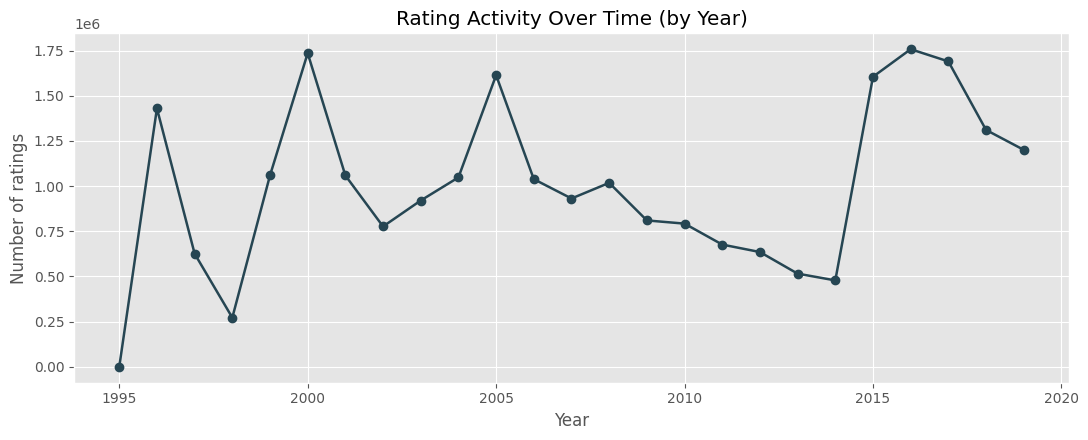

,rating_year,rating_count
0,1995,3
1,1996,1430093
2,1997,626202
3,1998,272099
4,1999,1059080
5,2000,1735398
6,2001,1058750
7,2002,776654
8,2003,920295
9,2004,1048116


,rating_year,rating_count
15,2010,792436
16,2011,676498
17,2012,635208
18,2013,515684
19,2014,478270
20,2015,1604971
21,2016,1757440
22,2017,1689935
23,2018,1310761
24,2019,1200634


In [10]:
# Time trends in rating activity by year
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(ratings_by_year_df["rating_year"].astype(int), ratings_by_year_df["rating_count"], marker="o", linewidth=1.8, color="#264653")
ax.set_title("Rating Activity Over Time (by Year)")
ax.set_xlabel("Year")
ax.set_ylabel("Number of ratings")
plt.tight_layout()
plt.show()

display(ratings_by_year_df.head(10))
display(ratings_by_year_df.tail(10))


This chart shows how the number of ratings changes over time, using the parsed rating timestamps. In everyday terms, it shows when the dataset is most active and whether user interaction volume is stable or concentrated in particular periods. The small head/tail tables below the chart make the timeline easier to verify by showing example years and counts from the beginning and end of the series.

This matters for the recommender app and offline evaluation because time-aware splits depend on timestamp quality and activity patterns. If rating activity changes significantly over time, a random split can hide temporal effects and overstate performance compared with a realistic chronological split.


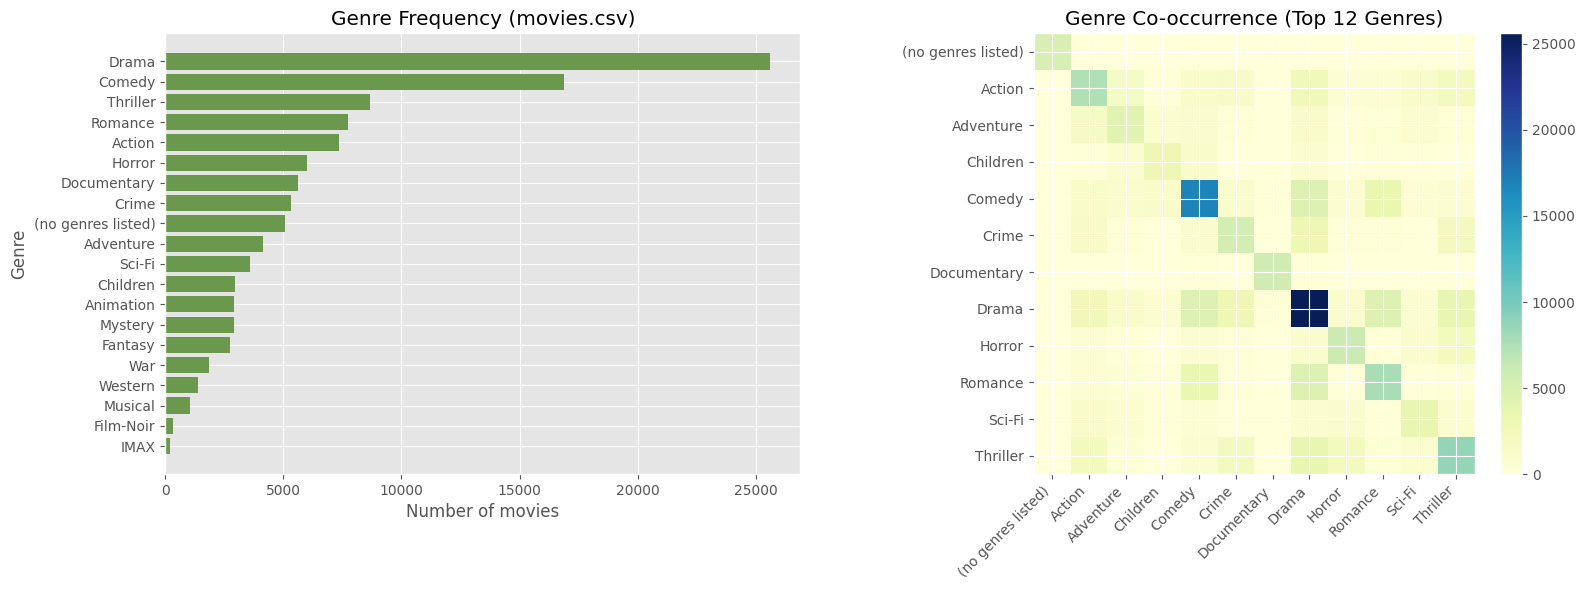

,genre,movie_count
0,Drama,25606
1,Comedy,16870
2,Thriller,8654
3,Romance,7719
4,Action,7348
5,Horror,5989
6,Documentary,5605
7,Crime,5319
8,(no genres listed),5062
9,Adventure,4145


genre,(no genres listed),Action,Adventure,Children,Comedy,Crime,Documentary,Drama,Horror,Romance,Sci-Fi,Thriller
genre,,,,,,,,,,,,
(no genres listed),5062,0,0,0,0,0,0,0,0,0,0,0
Action,0,7348,1652,198,1333,1423,37,2406,551,543,1185,2209
Adventure,0,1652,4145,839,1004,240,73,1138,165,436,635,470
Children,0,198,839,2935,1169,52,30,691,27,208,178,36
Comedy,0,1333,1004,1169,16870,1044,200,4603,790,3450,577,647
Crime,0,1423,240,52,1044,5319,62,2996,288,397,88,2065
Documentary,0,37,73,30,200,62,5605,245,35,27,26,29
Drama,0,2406,1138,691,4603,2996,245,25606,936,4654,679,3510
Horror,0,551,165,27,790,288,35,936,5989,129,933,2181


In [11]:
# Genre frequency and genre co-occurrence (from movies.csv)
movies_genre_long_df = (
    movies_df[["movieId", "genres"]]
    .assign(genres=lambda d: d["genres"].fillna("(no genres listed)"))
    .assign(genre=lambda d: d["genres"].str.split(r"\|"))
    .explode("genre")
)
movies_genre_long_df["genre"] = movies_genre_long_df["genre"].astype("string").str.strip()
movies_genre_long_df = movies_genre_long_df.dropna(subset=["genre"])

genre_frequency_df = (
    movies_genre_long_df.groupby("genre")["movieId"]
    .nunique()
    .sort_values(ascending=False)
    .rename("movie_count")
    .reset_index()
)

# Co-occurrence on the most common genres to keep the heatmap readable
TOP_GENRE_COUNT = 12
top_genres = genre_frequency_df["genre"].head(TOP_GENRE_COUNT).tolist()
movie_genre_pairs = (
    movies_genre_long_df[movies_genre_long_df["genre"].isin(top_genres)][["movieId", "genre"]]
    .drop_duplicates()
    .reset_index(drop=True)  # avoid duplicate index labels after explode/filter
)
movie_genre_matrix = pd.crosstab(
    index=movie_genre_pairs["movieId"].to_numpy(),
    columns=movie_genre_pairs["genre"].to_numpy(),
)
movie_genre_matrix.index.name = "movieId"
movie_genre_matrix.columns.name = "genre"
genre_cooccurrence_df = movie_genre_matrix.T.dot(movie_genre_matrix)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(genre_frequency_df["genre"].iloc[::-1], genre_frequency_df["movie_count"].iloc[::-1], color="#6a994e")
axes[0].set_title("Genre Frequency (movies.csv)")
axes[0].set_xlabel("Number of movies")
axes[0].set_ylabel("Genre")

im = axes[1].imshow(genre_cooccurrence_df.values, cmap="YlGnBu")
axes[1].set_title(f"Genre Co-occurrence (Top {TOP_GENRE_COUNT} Genres)")
axes[1].set_xticks(range(len(genre_cooccurrence_df.columns)))
axes[1].set_xticklabels(genre_cooccurrence_df.columns, rotation=45, ha="right")
axes[1].set_yticks(range(len(genre_cooccurrence_df.index)))
axes[1].set_yticklabels(genre_cooccurrence_df.index)
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

display(genre_frequency_df.head(15))
display(genre_cooccurrence_df)


The genre frequency chart shows how common each genre label is across `movies.csv`, while the co-occurrence heatmap shows how often the most common genres appear together in the same movies. In plain language, this is a quick way to understand the content vocabulary the app can use for filtering and basic content-based recommendations. The two tables below the figures support the visuals by listing the top genre counts and the exact co-occurrence matrix values used in the heatmap.

This matters because genre metadata is one of the cheapest and most explainable signals available in v1. Genre frequency affects how often a filter will return meaningful results, and genre co-occurrence helps anticipate where "similar in genre" explanations may be broad or ambiguous.


## 5. Sparsity and Cold-Start Analysis

Sparsity is one of the defining properties of recommender datasets. Even when a dataset has millions of ratings, the user-item matrix is still mostly empty because each user rates only a tiny fraction of the catalog. This section quantifies that sparsity and translates it into practical cold-start and low-activity risks for the app.


In [12]:
n_users = ratings_df["userId"].nunique()
n_movies = ratings_df["movieId"].nunique()
n_interactions = len(ratings_df)

matrix_size = n_users * n_movies
density = n_interactions / matrix_size
sparsity = 1 - density

thresholds = [1, 5, 10, 20, 50]
user_low_activity_df = pd.DataFrame(
    {
        "threshold_ratings": thresholds,
        "share_users_with_<=_threshold": [float((user_stats_df["rating_count"] <= t).mean()) for t in thresholds],
        "share_users_with_<_threshold": [float((user_stats_df["rating_count"] < t).mean()) for t in thresholds],
    }
)

movie_low_interaction_df = pd.DataFrame(
    {
        "threshold_ratings": thresholds,
        "share_movies_with_<=_threshold": [float((movie_stats_df["rating_count"] <= t).mean()) for t in thresholds],
        "share_movies_with_<_threshold": [float((movie_stats_df["rating_count"] < t).mean()) for t in thresholds],
    }
)

sparsity_summary_df = pd.DataFrame(
    [
        {"metric": "Unique users", "value": int(n_users)},
        {"metric": "Unique movies (in ratings)", "value": int(n_movies)},
        {"metric": "Observed interactions", "value": int(n_interactions)},
        {"metric": "User-item matrix size", "value": int(matrix_size)},
        {"metric": "Matrix density", "value": float(density)},
        {"metric": "Matrix sparsity", "value": float(sparsity)},
    ]
)

display(sparsity_summary_df)
display(user_low_activity_df)
display(movie_low_interaction_df)


,metric,value
0,Unique users,1.625410e+05
1,Unique movies (in ratings),5.904700e+04
2,Observed interactions,2.500010e+07
3,User-item matrix size,9.597558e+09
4,Matrix density,2.604839e-03
5,Matrix sparsity,9.973952e-01


,threshold_ratings,share_users_with_<=_threshold,share_users_with_<_threshold
0,1,0.000000,0.000000
1,5,0.000000,0.000000
2,10,0.000000,0.000000
3,20,0.028368,0.000000
4,50,0.378163,0.369439


,threshold_ratings,share_movies_with_<=_threshold,share_movies_with_<_threshold
0,1,0.174403,0.000000
1,5,0.488424,0.445865
2,10,0.604434,0.587955
3,20,0.692956,0.687876
4,50,0.778363,0.776856


The sparsity summary quantifies how small the observed interaction set is compared with the full user-item matrix. The threshold tables then show how much of the dataset sits in the low-activity and low-interaction regions that make collaborative recommendation harder.

This matters because collaborative filtering works best when users and items have enough interaction history to estimate meaningful similarity or latent factors. A high share of low-activity users or low-interaction movies increases cold-start pressure and supports the project plan to include strong popularity and metadata-based fallback paths in v1.


## 6. Feature Availability Assessment (What the Data Can Support)

At this point, the notebook has shown that the dataset is large and useful, but also sparse and uneven. The next question is not "what model is best" yet, but rather "what signals are realistically available at inference time and how expensive are they to use?" This is the bridge between U-Phase and the AAA phase.

The table below summarizes the main feature sources in terms of what recommendation approaches they support and whether they are a practical fit for the first Streamlit version.

| Data source | Main signals | Supports content-based? | Supports collaborative? | v1 recommendation | Notes |
| --- | --- | --- | --- | --- | --- |
| `ratings.csv` | userId, movieId, rating, timestamp | Indirectly (via rating-derived similarity) | Yes (core) | Use in v1 | Essential for personalization, popularity baselines, and evaluation. |
| `movies.csv` | title, genres | Yes (core) | No (directly) | Use in v1 | Essential for display, filters, and simple explainable content features. |
| `tags.csv` | user tags + timestamp | Yes (enrichment) | Indirectly | Optional / evaluate in AAA | Helpful for explanations and content enrichment; text cleaning required. |
| `links.csv` | IMDb/TMDb IDs | No (model signal) | No | Optional utility | Useful for posters/metadata integration in app UX, not core ranking logic. |
| `genome-tags.csv` + `genome-scores.csv` | dense tag relevance vectors | Yes (advanced) | Indirectly (hybrid features) | Defer unless quality gain justifies cost | Powerful but heavy; likely too expensive for v1 runtime path without precomputation. |

What this table shows is that the dataset already supports a solid v1 recommender without full genome features. The strongest low-cost combination for early modeling is `ratings.csv` + `movies.csv`, with `tags.csv` as an optional enrichment depending on metric gain and runtime impact.

Why this matters for the app is that explainability and responsiveness depend on feature choice as much as model choice. Cheaper features with clear semantics (ratings history and genres) are often the right first step for a Streamlit demo, especially when they can be precomputed and cached.


## 7. Train / Validation / Test Split Strategy (Leakage-Safe)

A recommender can look artificially strong if the evaluation split allows information from the future to leak into training features or popularity statistics. For this project, both `DATA.md` and `DECISIONS.md` explicitly require chronological splitting to reduce leakage risk and align offline evaluation with real usage.

In plain language, the model should learn from what happened earlier and be tested on what happened later. That is much closer to the real product scenario than a random split, where a user's future interactions may accidentally help predict their past behavior.

### Recommended split approach for AAA
The preferred strategy for the next phase is a **per-user chronological holdout**. For each user with enough interactions, earlier ratings go to training, and later ratings are reserved for validation and test. Users with too few interactions will need threshold-based handling so the evaluation remains meaningful.

### Why random splits can mislead in recommender systems
Random splits mix older and newer interactions together. In a recommender setting, this can leak future preference information into train-time statistics (for example popularity, co-occurrence, or similarity estimates), which often inflates ranking scores. The result is a model that looks better offline than it behaves when predicting truly future choices.

### Leakage risks to avoid (carried into AAA)
The main leakage risks are using future interactions in popularity/co-occurrence features, fitting transforms on train+test combined data, and building temporal features with centered windows that peek ahead. The project should also document which metadata are treated as static and available at prediction time.

```text
Per-user chronological holdout (recommended)

User history timeline:  [ older ratings ............. newer ratings ]
                         |----------- train --------|-- val --|-- test --|

What changes across users:
- some users have enough history for train/val/test
- low-activity users may require reduced holdout or exclusion for fair evaluation
```

This diagram shows the intended direction of time in evaluation: training uses earlier events, and validation/test use later events. That ordering matters because the app will always recommend a user's next items from their past behavior, not the other way around.


## 8. Data Pipeline Diagram (U-Phase View)

```text
ml-25m/ratings.csv  ----->  interactions table (cleaned + parsed timestamps)  ----->
                                                                                  |
ml-25m/movies.csv   ----->  movie metadata table (title + genres)  --------------> |--> U-Phase EDA summaries
                                                                                  |    (quality, sparsity, long-tail, time)
ml-25m/tags.csv     ----->  optional tag features / text cleanup  ----------------> |
                                                                                  |
ml-25m/links.csv    ----->  external ID lookup (posters/metadata UX)  -----------> |
                                                                                  |
ml-25m/genome-*     ----->  advanced content features (selective, optional)  ----> |

U-Phase outputs (for AAA planning):
- validated schemas and quality assumptions
- sparsity and cold-start evidence
- candidate feature availability decisions
- leakage-safe split rationale
```

This diagram shows how the raw `ml-25m` files translate into the cleaned tables and summaries used during U-Phase. The arrows indicate data flow, not model training. It separates the core v1 path (`ratings.csv` + `movies.csv`) from optional enrichment paths (`tags.csv`, `links.csv`, and genome features).

Why this matters for the recommender app is that it makes later implementation boundaries clearer: U-Phase produces evidence and decisions, AAA produces models and artifacts, and the Streamlit app should load those artifacts rather than rerunning heavy preprocessing each time.


## 9. U-Phase Summary and What Moves to AAA

The U-Phase analysis establishes that `ml-25m` is a strong dataset for an educational and demo-ready movie recommender, but also confirms the practical constraints that shaped the Q-Phase. The dataset is large, historically rich, and well documented, yet still highly sparse in the user-item matrix and uneven in user/item activity. Those patterns make fallback strategies and leakage-safe evaluation non-optional.

The most important outcome for the next phase is that the project has a credible low-cost feature path for v1: `ratings.csv` and `movies.csv` provide enough signal to build popularity baselines, genre-filtered recommendations, and collaborative or hybrid candidates that remain explainable in Streamlit. `tags.csv` is a useful enrichment candidate, while `genome-scores.csv` should be treated as an advanced option that must justify its runtime and complexity cost with clear quality gains.

In AAA, the project should carry forward the quality assumptions validated here, adopt a chronological split strategy, and compare simple baselines before introducing more complex recommenders. That keeps the modeling phase aligned with both the dataset evidence and the project goal of a fast, explainable, and reproducible recommendation app.

A concise handoff for AAA is shown below.

| Move forward into AAA now | Postpone unless justified by quality gain |
| --- | --- |
| `ratings.csv` (core interactions + timestamps) | Full `genome-scores.csv` feature integration in v1 runtime path |
| `movies.csv` (title/genres for filtering + content cues) | Heavy content pipelines that slow iteration without clear metric gains |
| `links.csv` for UX enrichment planning (optional utility) | Production-style metadata enrichment and API scaling concerns |
| `tags.csv` as a controlled enrichment experiment | Any train-time feature that leaks future interactions |

What this handoff table shows is not only what the project will use next, but also what it will intentionally defer. That matters because a clear non-scope for features and pipelines is part of keeping the Streamlit v1 app responsive and the AAA evaluation honest.
